# Notebook 5: branch tracking VS parameter

The goal is to stop thinking of labels as static and instead see them as something you track while a Hamiltonian parameter changes.
You want to answer:
1. Which dressed state at parameter value $\lambda + d\lambda$ is the continuation of a chosen dressed state at $\lambda$?
2. When does that continuation become ambiguous?
3. How do avoided crossings show up in overlaps and branch identity?
This is not exactly the same as scqubits’ internal branch-analysis algorithm. Branch analysis labels dressed states at a fixed Hamiltonian. Here we are doing a second layer of analysis: tracking a chosen dressed state across a parameter sweep.


# Main concept

Suppose the Hamiltonian depends on a parameter $\$$ |lambda $\$$ :

$$
H(\lambda)\left|\psi_k(\lambda)\right\rangle=E_k(\lambda)\left|\psi_k(\lambda)\right\rangle .
$$


If you pick one dressed state at $\$ \mathrm{lambda} \mathrm{\_i} \$$, then at the next parameter point $\$ \backslash$ lambda_\{i+1\}\$ you identify its continuation by maximal state overlap:

$$
\text { continuation of }\left|\psi_k\left(\lambda_i\right)\right\rangle=\arg \max _j\left|\left\langle\psi_j\left(\lambda_{i+1}\right) \mid \psi_k\left(\lambda_i\right)\right\rangle\right|^2 .
$$


That is the basic tracking rule.

Far from avoided crossings, this works very cleanly.

Near an avoided crossing, two states can exchange character, and then:
- energy ordering alone becomes misleading,
- bare-label intuition can become misleading,
- overlap tracking reveals the real continuity.

# Workshop 5: Tracking a dressed branch as a parameter changes

In this notebook, we study how a dressed state evolves as one Hamiltonian parameter is varied.

This is different from fixed-Hamiltonian branch analysis:

- branch analysis assigns dressed states meaningful bare-style labels at one parameter point
- branch tracking follows a selected dressed state continuously across multiple parameter points

We will:

1. build a transmon-resonator system
2. sweep one parameter
3. diagonalize at each point
4. track one chosen dressed state by overlap
5. compare tracked identity against simple energy ordering
6. visualize avoided-crossing behavior

In [1]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

## Step 1. Define a base transmon-resonator model

We will sweep the resonator frequency.

That is often a clean way to create near-resonance conditions and observe hybridization.

In [2]:
EJ = 25.0
EC = 1.0
ng = 0.0
ncut = 35
tmon_dim = 4
res_dim = 8
g = 0.30

tmon = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ng=ng,
    ncut=ncut,
    truncated_dim=tmon_dim
)

## Step 2. Define a helper function that constructs the Hilbert space

In [5]:
def build_hilbertspace(res_freq):
    res = scq.Oscillator(
        E_osc=res_freq,
        truncated_dim=res_dim
    )

    hs = scq.HilbertSpace([tmon, res])
    hs.add_interaction(
        g_strength=g,
        op1=tmon.n_operator,
        op2=res.creation_operator,
        add_hc=True # Adding the Hermitian conjugate of the interaction term. 
        )
    return hs

## Step 3. Sweep resonator frequency and diagonalize

We store energies and eigenvectors at each parameter point.

In [6]:
res_freqs = np.linspace(4.5, 7.5, 61)
evals_count = 12

all_evals = []
all_evecs = []

for freq in res_freqs:
    hs = build_hilbertspace(freq)
    evals, evecs = hs.eigensys(evals_count=evals_count)
    all_evals.append(evals)
    all_evecs.append(evecs)

all_evals = np.array(all_evals)

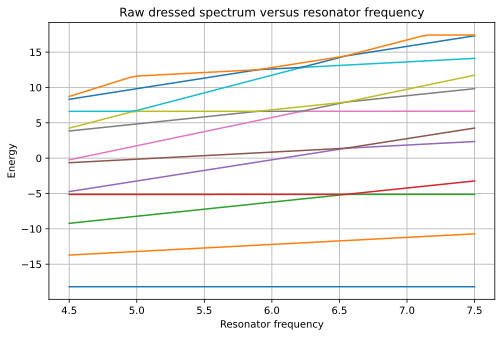

In [7]:
plt.figure(figsize=(8,5))
for k in range(evals_count):
    plt.plot(res_freqs, all_evals[:, k])
plt.xlabel("Resonator frequency")
plt.ylabel("Energy")
plt.title("Raw dressed spectrum versus resonator frequency")
plt.grid(True)
plt.show()

## Step 4. Pick one initial dressed state

We choose an initial parameter point and a dressed-state index there.
Then we follow its continuation by overlap.

In [9]:
start_idx = 0
tracked_state_initial = 3

psi_ref = all_evecs[start_idx][tracked_state_initial]

print("Initial resonator frequency:", res_freqs[start_idx])
print("Initial dressed index:", tracked_state_initial)
print("Initial energy:", all_evals[start_idx, tracked_state_initial])

Initial resonator frequency: 4.5
Initial dressed index: 3
Initial energy: -5.132577434893705


## Step 5. Track the state forward by maximal overlap

At each next parameter point, choose the dressed state with largest overlap with the previously tracked state.

In [13]:
tracked_indices = [tracked_state_initial]
tracked_energies = [all_evals[start_idx, tracked_state_initial]]
tracking_confidence = []

current_vec = all_evecs[start_idx][tracked_state_initial]

for step in range(start_idx + 1, len(res_freqs)):
    overlaps = []
    for j in range(evals_count):
        cand = all_evecs[step][j]
        ov = np.abs(np.vdot(cand, current_vec))**2
        overlaps.append(ov)

    overlaps = np.array(overlaps)
    best_j = np.argmax(overlaps)

    tracked_indices.append(best_j)
    tracked_energies.append(all_evals[step, best_j])
    tracking_confidence.append(overlaps[best_j])

    current_vec = all_evecs[step][best_j]

tracked_indices = np.array(tracked_indices)
tracked_energies = np.array(tracked_energies)
tracking_confidence = np.array(tracking_confidence)

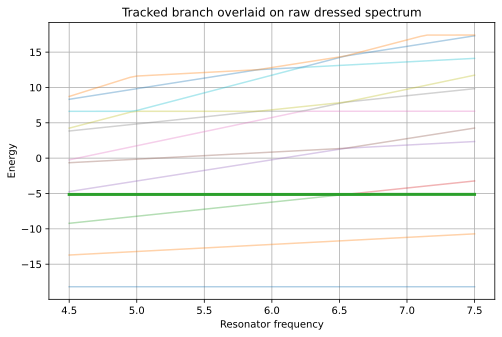

In [14]:
plt.figure(figsize=(8,5))
for k in range(evals_count):
    plt.plot(res_freqs, all_evals[:, k], alpha=0.35)

plt.plot(
    res_freqs[start_idx:],
    tracked_energies,
    linewidth=3
)

plt.xlabel("Resonator frequency")
plt.ylabel("Energy")
plt.title("Tracked branch overlaid on raw dressed spectrum")
plt.grid(True)
plt.show()

## Step 6. Plot tracking confidence

The best overlap at each step gives a simple measure of how unambiguous the continuation is.
If this becomes small, the state identity is changing rapidly.

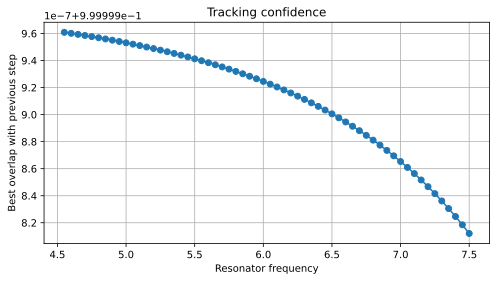

In [15]:
plt.figure(figsize=(8,4))
plt.plot(res_freqs[start_idx+1:], tracking_confidence, marker='o')
plt.xlabel("Resonator frequency")
plt.ylabel("Best overlap with previous step")
plt.title("Tracking confidence")
plt.grid(True)
plt.show()

## Step 7. Compare tracked identity to fixed energy index

A very common mistake is to assume that "state 3" at one parameter value is still "state 3" at another parameter value.

This is generally false near avoided crossings.

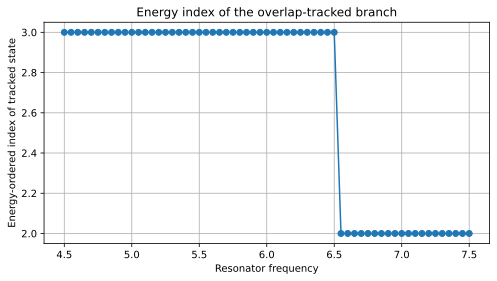

In [16]:
plt.figure(figsize=(8,4))
plt.plot(res_freqs[start_idx:], tracked_indices, marker='o')
plt.xlabel("Resonator frequency")
plt.ylabel("Energy-ordered index of tracked state")
plt.title("Energy index of the overlap-tracked branch")
plt.grid(True)
plt.show()

## Step 8. Inspect bare-state content at selected points

We now look at the bare decomposition of the tracked branch at three parameter values:
- before a crossing
- near a crossing
- after a crossing

In [20]:
def bare_labels_list(tmon_dim, res_dim):
    labels = []
    for t in range(tmon_dim):
        for r in range(res_dim):
            labels.append((t, r))
    return labels

bare_labels = bare_labels_list(tmon_dim, res_dim)

def print_top_components(evecs, state_index, evals, top_n=8):

    vec = evecs[state_index].full().flatten()
    probs = np.abs(vec)**2

    order = np.argsort(probs)[::-1]

    print(f"Dressed index = {state_index}, energy = {evals[state_index]:.6f}")

    for idx in order[:top_n]:
        print(f"  bare {bare_labels[idx]}: {probs[idx]:.6f}")

In [21]:
sample_steps = [10, 30, 50]

for step in sample_steps:
    hs = build_hilbertspace(res_freqs[step])
    evals, evecs = hs.eigensys(evals_count=evals_count)

    if step < start_idx:
        continue

    tracked_local = tracked_indices[step - start_idx]

    print()
    print("Resonator frequency =", res_freqs[step])
    print_top_components(evecs, tracked_local, evals, top_n=6)


Resonator frequency = 5.0
Dressed index = 3, energy = -5.131803
  bare (1, 0): 0.998401
  bare (0, 1): 0.001127
  bare (2, 1): 0.000472
  bare (3, 0): 0.000000
  bare (3, 2): 0.000000
  bare (1, 2): 0.000000

Resonator frequency = 6.0
Dressed index = 3, energy = -5.130072
  bare (1, 0): 0.998112
  bare (0, 1): 0.001468
  bare (2, 1): 0.000420
  bare (1, 2): 0.000000
  bare (3, 0): 0.000000
  bare (3, 2): 0.000000

Resonator frequency = 7.0
Dressed index = 2, energy = -5.127966
  bare (1, 0): 0.997635
  bare (0, 1): 0.001989
  bare (2, 1): 0.000376
  bare (1, 2): 0.000000
  bare (3, 0): 0.000000
  bare (3, 2): 0.000000


## Step 9. Use scqubits branch analysis at selected parameter points

Now we combine:
- parameter tracking across points
- branch analysis at individual points

In [22]:
for step in sample_steps:
    hs = build_hilbertspace(res_freqs[step])
    hs.eigensys(evals_count=evals_count)
    hs.generate_lookup(ordering="LX")

    print()
    print("Resonator frequency =", res_freqs[step])
    print([name for name in dir(hs) if "lookup" in name.lower() or "index" in name.lower()])

    for name in ["lookup", "_lookup"]:
        if hasattr(hs, name):
            print(f"{name}:")
            print(getattr(hs, name))


Resonator frequency = 5.0
['_generate_lookup_by_overlap', '_lookup_exists', 'bare_index', 'dressed_index', 'energy_by_bare_index', 'energy_by_dressed_index', 'generate_lookup', 'get_subsys_index', 'lookup_exists', 'set_npindextuple']

Resonator frequency = 6.0
['_generate_lookup_by_overlap', '_lookup_exists', 'bare_index', 'dressed_index', 'energy_by_bare_index', 'energy_by_dressed_index', 'generate_lookup', 'get_subsys_index', 'lookup_exists', 'set_npindextuple']

Resonator frequency = 7.0
['_generate_lookup_by_overlap', '_lookup_exists', 'bare_index', 'dressed_index', 'energy_by_bare_index', 'energy_by_dressed_index', 'generate_lookup', 'get_subsys_index', 'lookup_exists', 'set_npindextuple']


Important physical lesson

There are two different notions of "same state":

1. Same energy-order index

This means:

$$
k=\text { constant. }
$$


This is often not physically meaningful across avoided crossings.

2. Same continuously connected eigenstate

This means:

$$
|\psi(\lambda+d \lambda)\rangle
$$

is identified by maximal overlap with

$$
|\psi(\lambda)\rangle .
$$


This is usually the physically meaningful notion of branch continuation.
That is why branch tracking is useful.

## Exercises

1. Repeat the notebook, but sweep coupling strength g instead of resonator frequency.

2. Change the initial tracked dressed state from 3 to 4 or 5.
   Which states show the clearest avoided-crossing behavior?

3. Make the parameter grid coarser.
   Does tracking confidence degrade?

4. Make the parameter grid finer.
   Does tracking become smoother?

5. Identify a point where the tracked energy-order index changes.
   Inspect the top bare components before and after that point.

6. Compare:
   - raw energy ordering
   - overlap-based branch tracking
   - fixed-point LX branch labels

   Write one paragraph describing how these three notions differ.